# Imports

In [1]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 27.5 MB/s  0:00:00


## Failsafe for Tigramite

In [2]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")

Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [3]:
import sys
!{sys.executable} -m pip install fredapi yfinance alpha_vantage

In [ ]:
import pandas as pd
import time
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from fredapi import Fred
import yfinance as yf
from alpha_vantage.foreignexchange import ForeignExchange 


import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp

# Scraping Data

## FredAPI

In [6]:
fred = Fred(api_key='b29fa8db713c7d9498fc161a88fb77ac')

#UNRATE: unemployment rate
#CPIAUCSL: consumer price index (inflaton)
#FEDFUNDS: effective federal funds rate (interest rates)
#GDPC1: Real Gross Domestic Product
#T10Y2Y: Yield Curve (recession indicator)
#TEDRATE: TED Spread (interbank credit risk)
#VIXLS: CBOE (market fear)
#BAMLH0A0HYM2: Bank of America's US High Yield Index (Credit risk)

indexes = ['UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'T10Y2Y', 'TEDRATE', 'VIXCLS', 'BAMLH0A0HYM2']

data = {}
for index in indexes:
    data[index] = fred.get_series(index)

df_macro = pd.DataFrame(data)
df_macro.index.name = 'Date'
df_macro = df_macro.loc['2000-01-01':]

## Yahoo Finance

In [7]:
#ticker symbols
# CL=F: crude oil futures
# GC=F: gold futures 
# XLE: energy select sector (correlation with oil)
# XLK: technology select sector
# XLF: financial sector (rate sensistive)
# GSPC: S and P 500 Index
# TNX: 10 year treasuring yield

tickers = ['CL=F', 'GC=F', 'XLE', 'XLK', 'XLF', '^GSPC', '^TNX']
df_sector = yf.download(tickers, start="2000-01-01", interval="1d", auto_adjust=True)['Close']

/Users/lauradiaz/miniforge3/envs/dev_mode_py312/lib/python3.12/site-packages/yfinance/scrapers/history.py:172: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  7 of 7 completed


## Creation of Main DataFrame

In [12]:
df_main = df_sector.join(df_macro, how='outer')#.join(df_fx, how='outer')
df_main.sort_index(inplace=True)

# forward fill bc market uses that monthly or weekly number
# df_main.fillna(method='ffill', inplace=True) (old pandas syntax)
df_main.ffill(inplace=True) # new pandas syntax [f.fillna(method="ffill") -> df.ffill()] & [df.fillna(method="bfill") -> df.bfill()]
df_main.dropna(inplace=True)
df_main

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,,,,,,,,
2000-08-30,33.400002,273.899994,8.264158,13.620223,20.652031,1502.589966,5.800,4.1,172.700,6.50,14145.312,-0.43,0.54,17.69,6.28
2000-08-31,33.099998,278.299988,8.232368,13.973000,21.059494,1517.680054,5.729,4.1,172.700,6.50,14145.312,-0.45,0.55,16.84,6.43
2000-09-01,33.380001,277.000000,8.315807,13.742926,21.071119,1520.770020,5.675,3.9,173.600,6.52,14145.312,-0.41,0.58,17.53,6.48
2000-09-04,33.380001,277.000000,8.315807,13.742926,21.071119,1520.770020,5.675,3.9,173.600,6.52,14145.312,-0.41,0.58,17.53,6.49
2000-09-05,33.799999,275.799988,8.315807,13.911644,20.593828,1507.079956,5.683,3.9,173.600,6.52,14145.312,-0.40,0.58,19.82,6.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03,74.559998,5107.399902,56.520000,51.209999,137.500000,6816.629883,4.056,4.4,326.588,3.64,24111.830,0.55,0.09,23.57,3.08
2026-03-04,74.660004,5120.200195,56.189999,51.500000,139.839996,6869.500000,4.080,4.4,326.588,3.64,24111.830,0.55,0.09,21.15,2.97
2026-03-05,81.010002,5065.299805,56.480000,51.230000,140.179993,6830.709961,4.146,4.4,326.588,3.64,24111.830,0.56,0.09,23.75,3.00


In [13]:
df_main.drop(columns=['GDPC1'], inplace=True)
df_main.drop(columns=['TEDRATE'], inplace=True)

# Data Preparation

In [14]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)

#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

/Users/lauradiaz/miniforge3/envs/dev_mode_py312/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
df_transform.shape

(6832, 13)

# SETUP & DATA PREP

In [16]:
data_source = df_transform

# standardize
scaler = StandardScaler()
values_scaled = scaler.fit_transform(data_source.values)
var_names = data_source.columns.tolist()

# chronological train/test split (80/20)
split_idx = int(len(values_scaled) * 0.8)
train_values = values_scaled[:split_idx]
test_values = values_scaled[split_idx:]

# Tigramite objects
train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
test_dataframe = dp.DataFrame(test_values, datatime=np.arange(len(test_values)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

print(f"Data prepped variables: {var_names}")
print(f"Training on {len(train_values)} days, testing on {len(test_values)} days")

Data prepped variables: ['CL=F', 'GC=F', 'XLE', 'XLF', 'XLK', '^GSPC', '^TNX', 'UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'T10Y2Y', 'VIXCLS', 'BAMLH0A0HYM2']
Training on 5465 days, testing on 1367 days


In [17]:
var_names

['CL=F',
 'GC=F',
 'XLE',
 'XLF',
 'XLK',
 '^GSPC',
 '^TNX',
 'UNRATE',
 'CPIAUCSL',
 'FEDFUNDS',
 'T10Y2Y',
 'VIXCLS',
 'BAMLH0A0HYM2']

# CAUSAL DISCOVERY

## Show All Relations

--- Running PCMCI Causal Discovery for Target: XLE ---

 FULL VARIABLE CHART (Target: XLE)
Alpha Threshold: 0.05
Index | Variable     | Lag  | Strength (MCI)  | P-Value    | Kept by PCMCI?
--------------------------------------------------------------------------------
0     | CL=F         | 3    |     0.0734      | 0.00000    | YES
12    | BAMLH0A0HYM2 | 1    |     0.0612      | 0.00001    | YES
8     | CPIAUCSL     | 3    |     0.0515      | 0.00015    | YES
2     | XLE          | 2    |    -0.0498      | 0.00024    | YES
7     | UNRATE       | 1    |     0.0495      | 0.00026    | YES
11    | VIXCLS       | 2    |    -0.0405      | 0.00285    | YES
10    | T10Y2Y       | 3    |    -0.0396      | 0.00348    | YES
7     | UNRATE       | 3    |     0.0393      | 0.00378    | YES
1     | GC=F         | 2    |     0.0376      | 0.00554    | YES
7     | UNRATE       | 5    |     0.0330      | 0.01487    | YES
10    | T10Y2Y       | 4    |    -0.0321      | 0.01780    | YES
11    | VIXCLS 

<Figure size 1000x1000 with 0 Axes>

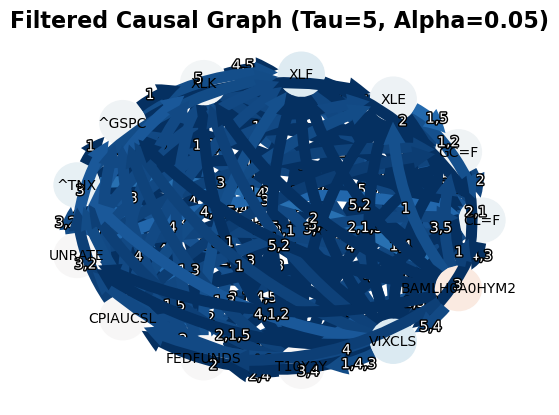

<Figure size 1000x1000 with 0 Axes>

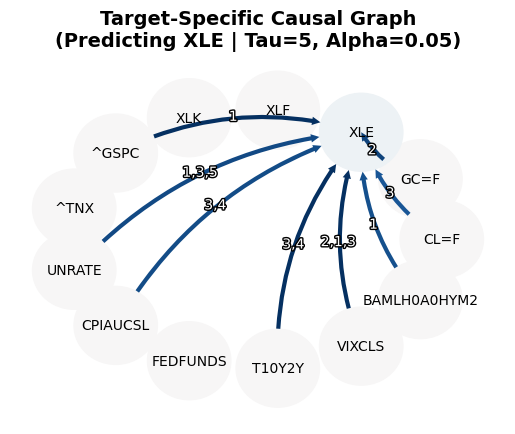

In [18]:
# --- HYPERPARAMETER CONTROL PANEL ---
TAU_MIN = 1       
TAU_MAX = 5       # maximum lookback window
ALPHA = 0.05      # significance threshold 
TARGET_VAR = 2    # index of variable to predict


target_name = var_names[TARGET_VAR]
print(f"--- Running PCMCI Causal Discovery for Target: {target_name} ---")

# run PCMCI
results = pcmci.run_pcmci(tau_min=TAU_MIN, tau_max=TAU_MAX, pc_alpha=ALPHA)

# extract matrices
graph = results['graph']
val_matrix = results['val_matrix']
p_matrix = results['p_matrix']

all_tested_relations = []

# scan every variable at every lag
for var_j in range(len(var_names)):
    for lag in range(TAU_MIN, TAU_MAX + 1): 
        strength = val_matrix[var_j, TARGET_VAR, lag]
        p_val = p_matrix[var_j, TARGET_VAR, lag]
        
        # Check if algorithm accepted variable based on alpha
        passed_test = "YES" if p_val <= ALPHA else "NO"
        
        all_tested_relations.append({
            "Variable": var_names[var_j],
            "Index": var_j,
            "Lag": lag,
            "Strength": strength,
            "P-Value": p_val,
            "Passed": passed_test
        })

# sort by strongest relations first (Absolute Strength)
all_tested_relations.sort(key=lambda x: abs(x["Strength"]), reverse=True)

# print all relations
print(f"\n FULL VARIABLE CHART (Target: {target_name})")
print(f"Alpha Threshold: {ALPHA}")
print(f"{'Index':<5} | {'Variable':<12} | {'Lag':<4} | {'Strength (MCI)':<15} | {'P-Value':<10} | {'Kept by PCMCI?'}")
print("-" * 80)

for p in all_tested_relations:
    # highlight variables that passed
    if p["Passed"] == "YES":
        print(f"{p['Index']:<5} | {p['Variable']:<12} | {p['Lag']:<4} | {p['Strength']:>10.4f}      | {p['P-Value']:<10.5f} | {p['Passed']}")
    else:
        #dim relations that failed 
        print(f"{p['Index']:<5} | {p['Variable']:<12} | {p['Lag']:<4} | {p['Strength']:>10.4f}      | {p['P-Value']:<10.5f} | {p['Passed']}")

filtered_graph = np.copy(graph)
filtered_val_matrix = np.copy(val_matrix)

# Blank out ANY edge in the entire system that failed the alpha test
for i in range(len(var_names)):
    for j in range(len(var_names)):
        for tau in range(TAU_MAX + 1):
            if p_matrix[i, j, tau] > ALPHA:
                filtered_graph[i, j, tau] = ""            # Remove the arrow
                filtered_val_matrix[i, j, tau] = 0.0      # Remove the color/strength

# Visualize the PRUNED Graph
plt.figure(figsize=(10, 10))
tp.plot_graph(
    val_matrix=filtered_val_matrix,
    graph=filtered_graph,
    var_names=var_names,
    vmin_edges=0.0,      # Set to 0 so we don't accidentally hide weak but significant links
    show_colorbar=False,
    label_fontsize=12
)
plt.title(f"Filtered Causal Graph (Tau={TAU_MAX}, Alpha={ALPHA})", fontsize=16, fontweight='bold')
plt.show()

filtered_graph = np.empty_like(graph)
filtered_graph.fill("") 
filtered_val_matrix = np.zeros_like(val_matrix) 

# Rebuild ONLY the edges that point to the TARGET and passed the test
for p in all_tested_relations:
    if p["Passed"] == "YES":
        i = p["Index"]
        tau = p["Lag"]
        
        # Copy the specific arrow from the original results to our clean slate
        filtered_graph[i, TARGET_VAR, tau] = graph[i, TARGET_VAR, tau]
        filtered_val_matrix[i, TARGET_VAR, tau] = val_matrix[i, TARGET_VAR, tau]

# 5. Visualize the Clean Graph
plt.figure(figsize=(10, 10))
tp.plot_graph(
    val_matrix=filtered_val_matrix,
    graph=filtered_graph,
    var_names=var_names,
    vmin_edges=0.0,      # Show everything we manually approved
    show_colorbar=False,
    label_fontsize=12,
    node_size=0.6,
    arrow_linewidth=3.0
)
plt.title(f"Target-Specific Causal Graph\n(Predicting {target_name} | Tau={TAU_MAX}, Alpha={ALPHA})", fontsize=14, fontweight='bold')
plt.show()

## Simple Predictive Model

In [19]:
# LINEAR REGRESSION & FEATURE SELECTION

# --- FEATURE SELECTION PANEL ---
# manually define the features you want to include in your regression.
# Format: (Variable_Index, Lag_Amount)
# You can get the Index from the var_names list printed in Block 1.

MANUAL_PREDICTORS = [
    # (Index, Lag)  # Comment (Name)
    (3, 2),         # GC=F (Gold) at Lag 2
    #(1, 5),        # Example: ^TNX at Lag 5 (Uncomment to test adding this)
    #(2, 5),        # Example: T10Y2Y at Lag 5 (Uncomment to test adding this)
]
# ----------------------------------

# ensure alignment by cutting off the max lag we might test
GLOBAL_CUTOFF = 10 
target_idx = TARGET_VAR 

def train_and_evaluate(train_data, test_data, features):
    # Fallback if list is empty
    if not features:
        print("No predictors selected. Using Autoregression (Target Lag 1).")
        features = [(target_idx, 1)]
        
    def build_xy(data):
        y = data[GLOBAL_CUTOFF:, target_idx]
        X_cols = []
        for (var_idx, lag) in features:
            col = np.roll(data[:, var_idx], shift=lag)[GLOBAL_CUTOFF:]
            X_cols.append(col)
        return np.column_stack(X_cols), y

    # Prepare Data Matrices
    X_train, y_train = build_xy(train_data)
    X_test, y_test   = build_xy(test_data)
    
    # Train & Test
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    
    return mse, model

# Run Evaluation
mse_result, trained_model = train_and_evaluate(train_values, test_values, MANUAL_PREDICTORS)

# Print Summary
print("\n--- REGRESSION RESULTS ---")
print("Features Used:")
for (idx, lag) in MANUAL_PREDICTORS:
    print(f"  -> {var_names[idx]} (Lag {lag})")
    
if not MANUAL_PREDICTORS:
    print(f"  -> {var_names[target_idx]} (Lag 1) [Fallback]")

print("-" * 30)
print(f"Test Set MSE: {mse_result:.5f}")


--- REGRESSION RESULTS ---
Features Used:
  -> XLF (Lag 2)
------------------------------
Test Set MSE: 0.82905


## Grid Search For Hyperparmeters

Starting Grid Search for Target Variable: 'XLE'
Testing 5 Lags and 5 Alphas (25 total models)

 Tau: 1 | Alpha: 0.01 | Predictors: 8  | MSE: 0.84188
 Tau: 1 | Alpha: 0.05 | Predictors: 3  | MSE: 0.84134
 Tau: 1 | Alpha: 0.1  | Predictors: 3  | MSE: 0.84134
 Tau: 1 | Alpha: 0.15 | Predictors: 3  | MSE: 0.84134
 Tau: 1 | Alpha: 0.2  | Predictors: 3  | MSE: 0.84134
 Tau: 2 | Alpha: 0.01 | Predictors: 14 | MSE: 0.84943
 Tau: 2 | Alpha: 0.05 | Predictors: 10 | MSE: 0.84789
 Tau: 2 | Alpha: 0.1  | Predictors: 7  | MSE: 0.84480
 Tau: 2 | Alpha: 0.15 | Predictors: 8  | MSE: 0.85001
 Tau: 2 | Alpha: 0.2  | Predictors: 7  | MSE: 0.84480
 Tau: 3 | Alpha: 0.01 | Predictors: 16 | MSE: 0.86210
 Tau: 3 | Alpha: 0.05 | Predictors: 10 | MSE: 0.86108
 Tau: 3 | Alpha: 0.1  | Predictors: 12 | MSE: 0.86340
 Tau: 3 | Alpha: 0.15 | Predictors: 12 | MSE: 0.86340
 Tau: 3 | Alpha: 0.2  | Predictors: 11 | MSE: 0.86144
 Tau: 4 | Alpha: 0.01 | Predictors: 18 | MSE: 0.86305
 Tau: 4 | Alpha: 0.05 | Predictors: 13 | 

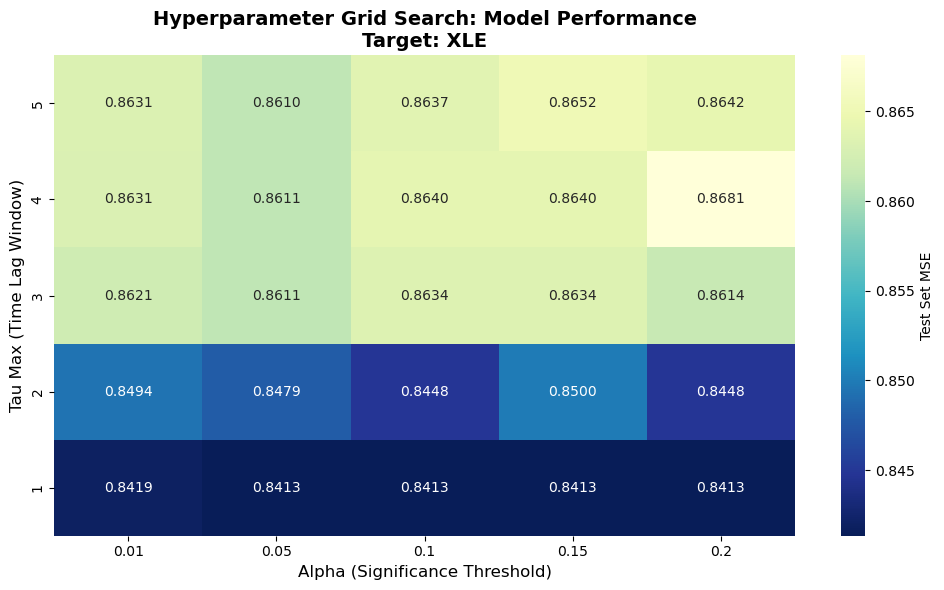

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

data_source = df_transform

# Standardize
scaler = StandardScaler()
values_scaled = scaler.fit_transform(data_source.values)
var_names = data_source.columns.tolist()

# Chronological Train/Test Split (80/20)
split_idx = int(len(values_scaled) * 0.8)
train_values = values_scaled[:split_idx]
test_values = values_scaled[split_idx:]

train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

# --- GRID SEARCH SETTINGS ---
TARGET_VAR = 2  # Index variable to predict
tau_max_list = [1, 2, 3, 4, 5]                  # different Time Lags to test
alpha_list = [0.01, 0.05, 0.10, 0.15, 0.20]     # different Alphas to test

# To ensure fair testing, ALL models must drop the same number of initial rows.
# We use the absolute maximum lag being tested as the universal cutoff.
GLOBAL_CUTOFF = max(tau_max_list) 

results_log = []

print(f"Starting Grid Search for Target Variable: '{var_names[TARGET_VAR]}'")
print(f"Testing {len(tau_max_list)} Lags and {len(alpha_list)} Alphas ({len(tau_max_list) * len(alpha_list)} total models)\n")

# EXPERIMENT LOOP 
for tau in tau_max_list:
    for alpha in alpha_list:
        
        # run causal discovery
        # always set tau_min=1 to enforce strictly predictive forecasting
        pcmci_res = pcmci.run_pcmci(tau_min=1, tau_max=tau, pc_alpha=alpha)
        
        graph = pcmci_res['graph']
        parents = []
        
        # extract discovered parents
        for var_j in range(len(var_names)):
            for lag in range(1, tau + 1):
                if graph[var_j, TARGET_VAR, lag] != "":
                    parents.append((var_j, lag))
                    
        # fallback if no parents are found (simple autoregression)
        if not parents:
            parents.append((TARGET_VAR, 1))
            
        # build regression matrices (X, y)
        def build_xy(data):
            y = data[GLOBAL_CUTOFF:, TARGET_VAR]
            X_cols = []
            for (var_idx, lag) in parents:
                col = np.roll(data[:, var_idx], shift=lag)[GLOBAL_CUTOFF:]
                X_cols.append(col)
            return np.column_stack(X_cols), y

        X_train, y_train = build_xy(train_values)
        X_test, y_test   = build_xy(test_values)
        
        # train and evaluate
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        
        # store results
        results_log.append({
            'Tau Max': tau,
            'Alpha': alpha,
            'MSE': mse,
            'Num Predictors': len(parents)
        })
        print(f" Tau: {tau} | Alpha: {alpha:<4} | Predictors: {len(parents):<2} | MSE: {mse:.5f}")

# --- PROCESS RESULTS ---
results_df = pd.DataFrame(results_log)

# find the best combination
best_run = results_df.loc[results_df['MSE'].idxmin()]
print("\n BEST MODEL FOUND:")
print(f"Tau Max: {int(best_run['Tau Max'])}")
print(f"Alpha:   {best_run['Alpha']}")
print(f"Features:{int(best_run['Num Predictors'])}")
print(f"MSE:     {best_run['MSE']:.5f}")

# --- PERFORMANCE HEATMAP ---
# create pivot table for the heatmap
heatmap_data = results_df.pivot(index='Tau Max', columns='Alpha', values='MSE')

plt.figure(figsize=(10, 6))
# colormap where lower MSE is blue-er and higher MSE is red-er
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu_r", cbar_kws={'label': 'Test Set MSE'})

plt.title(f"Hyperparameter Grid Search: Model Performance\nTarget: {var_names[TARGET_VAR]}", fontsize=14, fontweight='bold')
plt.xlabel("Alpha (Significance Threshold)", fontsize=12)
plt.ylabel("Tau Max (Time Lag Window)", fontsize=12)
plt.gca().invert_yaxis() # Put lowest lag at the top
plt.tight_layout()
plt.show()

## Comparing Baseline to Specialized

Running Causal Discovery 

------------------------------------------------------------
 CAUSAL BENCHMARK PROOF 
------------------------------------------------------------
BASELINE (Tau=5, Alpha=0.05)
  - Avg Edges Discovered per Target: 17.8 predictors
  - Out-of-Sample Predictive Error:  0.89729
------------------------------------------------------------
SPECIALIZED (Tau=1, Alpha=0.2)
  - Avg Edges Discovered per Target: 4.0 predictors
  - Out-of-Sample Predictive Error:  0.87790
------------------------------------------------------------


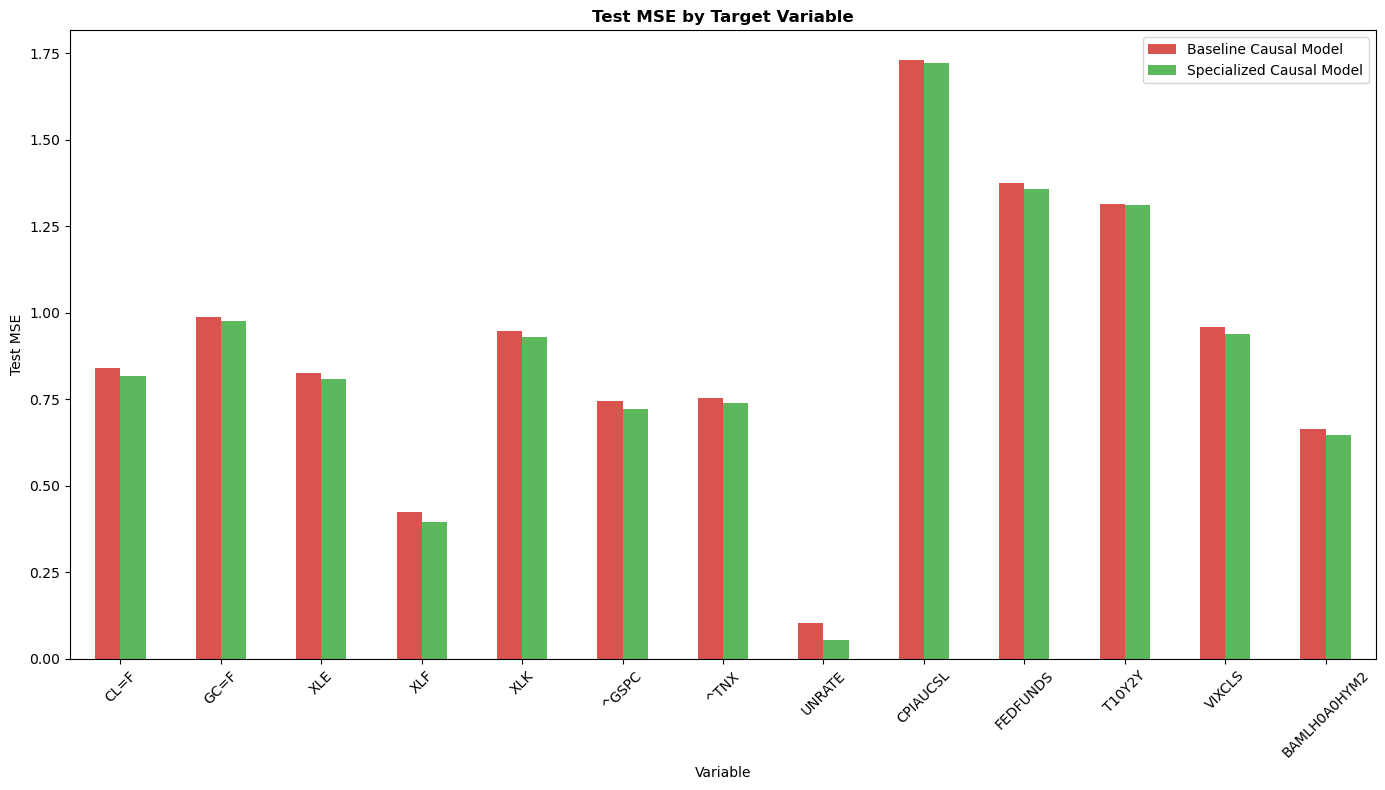

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

# --- DATA SPLITTING ---
data_source = df_transform
var_names = data_source.columns.tolist()

split_idx = int(len(data_source) * 0.8)
train_raw = data_source.values[:split_idx]
test_raw = data_source.values[split_idx:]

scaler = StandardScaler()
train_values = scaler.fit_transform(train_raw)
test_values = scaler.transform(test_raw)

train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

# --- CAUSAL DISCOVERY MODEL PARAMETERS ---
TAU_BASELINE = 5
ALPHA_BASELINE = 0.05

TAU_SPECIALIZED = 1
ALPHA_SPECIALIZED = 0.20

GLOBAL_CUTOFF = max(TAU_BASELINE, TAU_SPECIALIZED)

print("Running Causal Discovery \n")
res_baseline = pcmci.run_pcmci(tau_min=1, tau_max=TAU_BASELINE, pc_alpha=ALPHA_BASELINE)
res_specialized = pcmci.run_pcmci(tau_min=1, tau_max=TAU_SPECIALIZED, pc_alpha=ALPHA_SPECIALIZED)

# helper to build strictly constrained features
def build_xy(data, target_idx, parents_list, cutoff):
    y = data[cutoff:, target_idx]
    X_cols = []
    for (var_idx, lag) in parents_list:
        col = np.roll(data[:, var_idx], shift=lag)[cutoff:]
        X_cols.append(col)
        
    if not X_cols: # if no true causes found, predict 0 (historical average)
        return np.zeros((len(y), 1)), y 
        
    return np.column_stack(X_cols), y

# --- CAUSAL EVALUATION LOOP ---
results_log = []

for target_idx in range(len(var_names)):
    target_name = var_names[target_idx]
    
    # --- extract baseline edges ---
    graph_base = res_baseline['graph']
    parents_base = [(var_j, lag) for var_j in range(len(var_names)) 
                    for lag in range(1, TAU_BASELINE + 1) if graph_base[var_j, target_idx, lag] != ""]
    
    # train simple model on Baseline
    X_train_base, y_train_base = build_xy(train_values, target_idx, parents_base, GLOBAL_CUTOFF)
    X_test_base, y_test_base = build_xy(test_values, target_idx, parents_base, GLOBAL_CUTOFF)
    
    model_base = LinearRegression() 
    model_base.fit(X_train_base, y_train_base)
    mse_base = mean_squared_error(y_test_base, model_base.predict(X_test_base))
    
    # --- extract specialized edges ---
    graph_spec = res_specialized['graph']
    parents_spec = [(var_j, lag) for var_j in range(len(var_names)) 
                    for lag in range(1, TAU_SPECIALIZED + 1) if graph_spec[var_j, target_idx, lag] != ""]
    
    # train simple model on Specialized
    X_train_spec, y_train_spec = build_xy(train_values, target_idx, parents_spec, GLOBAL_CUTOFF)
    X_test_spec, y_test_spec = build_xy(test_values, target_idx, parents_spec, GLOBAL_CUTOFF)
    
    model_spec = LinearRegression() 
    model_spec.fit(X_train_spec, y_train_spec)
    mse_spec = mean_squared_error(y_test_spec, model_spec.predict(X_test_spec))
    
    results_log.append({
        'Variable': target_name,
        'Base_MSE': mse_base,
        'Spec_MSE': mse_spec,
        'Base_Edges': len(parents_base),
        'Spec_Edges': len(parents_spec)
    })

# --- CAUSAL PROOF ANALYSIS ---
df_res = pd.DataFrame(results_log)

avg_base_mse = df_res['Base_MSE'].mean()
avg_spec_mse = df_res['Spec_MSE'].mean()
avg_base_edges = df_res['Base_Edges'].mean()
avg_spec_edges = df_res['Spec_Edges'].mean()

mse_improvement = ((avg_base_mse - avg_spec_mse) / avg_base_mse) * 100

print("-"*60)
print(" CAUSAL BENCHMARK PROOF ")
print("-"*60)
print(f"BASELINE (Tau={TAU_BASELINE}, Alpha={ALPHA_BASELINE})")
print(f"  - Avg Edges Discovered per Target: {avg_base_edges:.1f} predictors")
print(f"  - Out-of-Sample Predictive Error:  {avg_base_mse:.5f}")
print("-" * 60)
print(f"SPECIALIZED (Tau={TAU_SPECIALIZED}, Alpha={ALPHA_SPECIALIZED})")
print(f"  - Avg Edges Discovered per Target: {avg_spec_edges:.1f} predictors")
print(f"  - Out-of-Sample Predictive Error:  {avg_spec_mse:.5f}")
print("-"*60)


# Visualization for specific variables
df_res.set_index('Variable')[['Base_MSE', 'Spec_MSE']].plot(kind='bar', figsize=(14, 8), color=['#d9534f', '#5cb85c'])
plt.title("Test MSE by Target Variable", fontweight='bold')
plt.ylabel("Test MSE")
plt.xticks(rotation=45)
plt.legend(["Baseline Causal Model", "Specialized Causal Model"])
plt.tight_layout()
plt.show()

# “Improvement” metrics relative to baseline

In [81]:
plt.rcParams.update({
    "font.family": "Avenir",
    "font.size": 22,

    "axes.titlesize": 30,
    "axes.labelsize": 26,

    "xtick.labelsize": 20,
    "ytick.labelsize": 20,

    "axes.titleweight": "bold",
    "axes.labelweight": "bold"
})

# -----------------------------
# Global style for poster figures
# -----------------------------
plt.rcParams.update({
    "font.family": "Avenir",   # matches Glacial Indifference closely
    "font.size": 22,               # base font size

    "axes.titlesize": 30,          # figure title
    "axes.labelsize": 26,          # axis labels

    "xtick.labelsize": 20,
    "ytick.labelsize": 20,

    "legend.fontsize": 20,

    "axes.linewidth": 1.2,

    "figure.dpi": 150,
    "savefig.dpi": 300
})

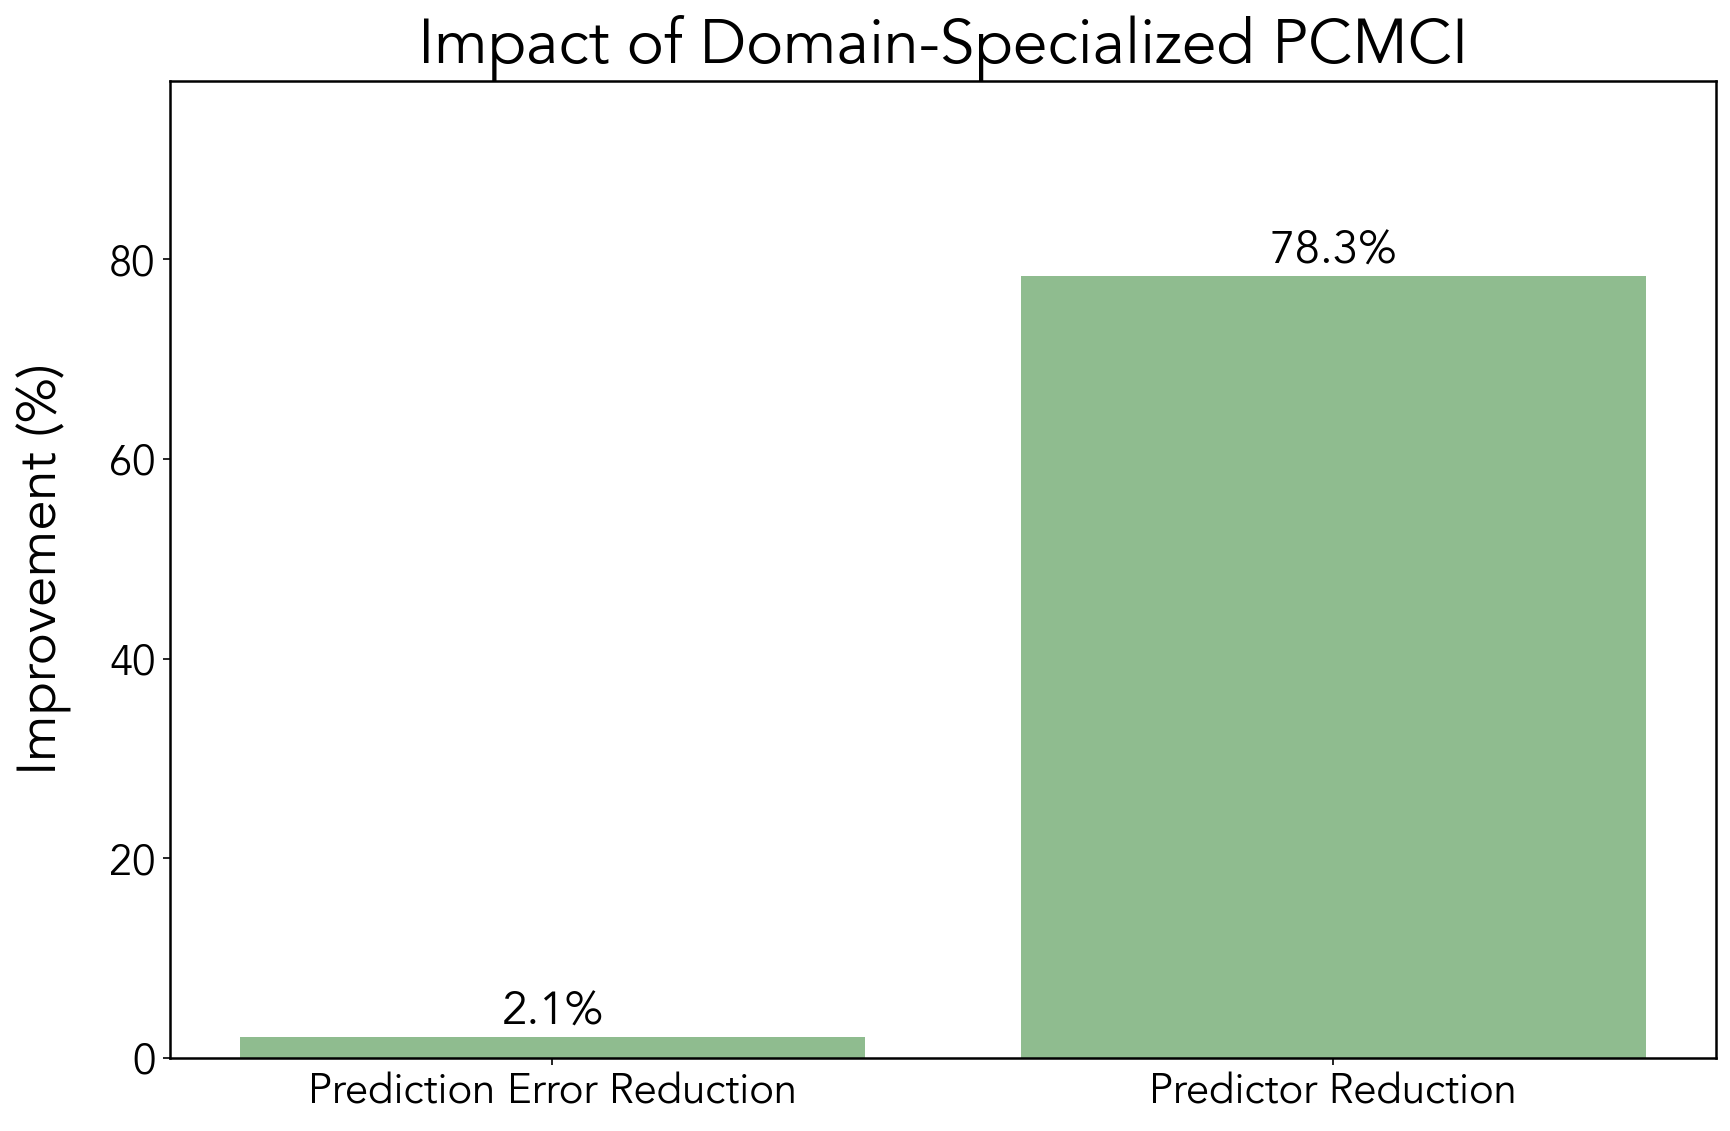

In [88]:
baseline_mse = 0.89524
specialized_mse = 0.87664
baseline_num_preds = 17.5
specialized_num_preds = 3.8

# compute improvements
mse_reduction = (baseline_mse - specialized_mse) / baseline_mse * 100
predictor_reduction = (baseline_num_preds - specialized_num_preds) / baseline_num_preds * 100

metrics = ["Prediction Error Reduction", "Predictor Reduction"]
values = [mse_reduction, predictor_reduction]

fig, ax = plt.subplots(figsize=(12,8))

bars = plt.bar(metrics, values, color="darkseagreen")

# add vertical padding above bars
ax.set_ylim(0, max(values) * 1.25)

ax.set_ylabel("Improvement (%)", labelpad=18)
plt.title("Impact of Domain-Specialized PCMCI")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.1f}%",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()

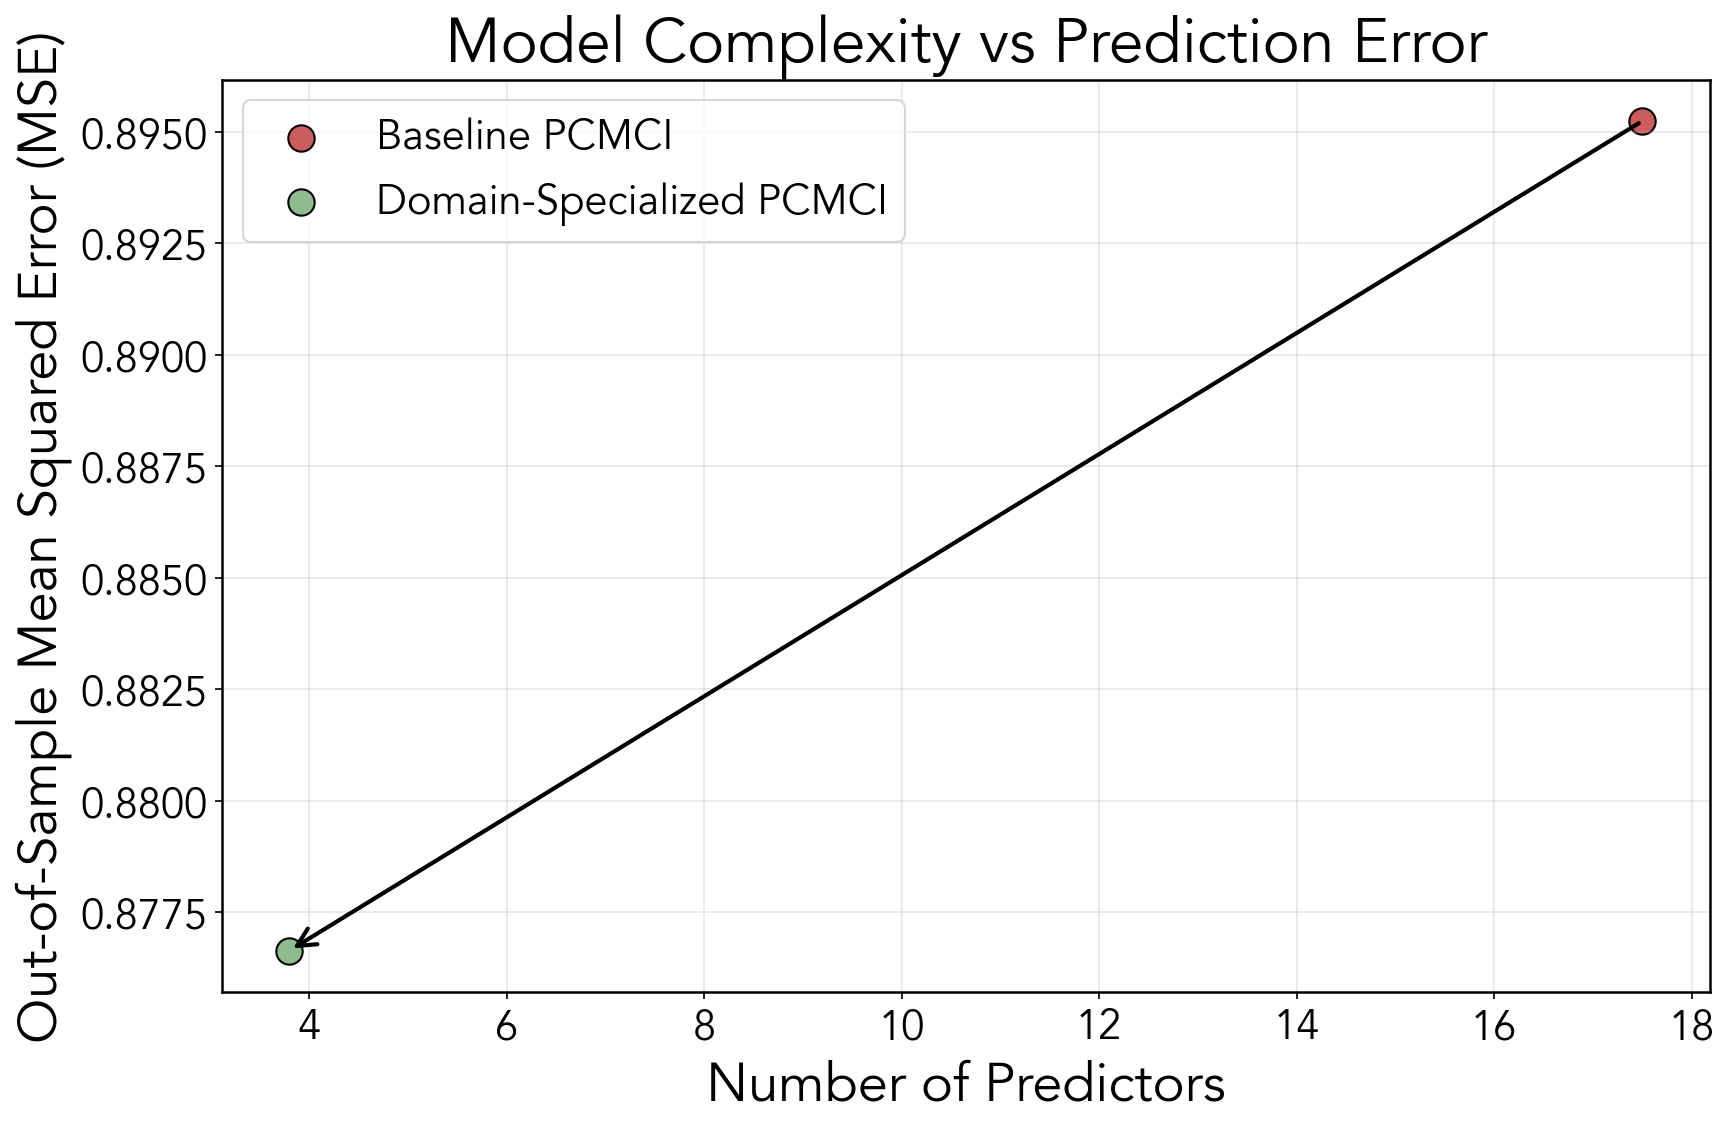

In [84]:
baseline_mse = 0.89524
specialized_mse = 0.87664
baseline_num_preds = 17.5
specialized_num_preds = 3.8

# determine which model is better
baseline_score = baseline_mse + baseline_num_preds
specialized_score = specialized_mse + specialized_num_preds

if specialized_score < baseline_score:
    colors = ["indianred", "darkseagreen"]
else:
    colors = ["darkseagreen", "indianred"]

plt.figure(figsize=(12, 8))

# plot points
plt.scatter(
    baseline_num_preds,
    baseline_mse,
    s=160,
    color=colors[0],
    edgecolor="black",
    label="Baseline PCMCI"
)

plt.scatter(
    specialized_num_preds,
    specialized_mse,
    s=160,
    color=colors[1],
    edgecolor="black",
    label="Domain-Specialized PCMCI"
)

# arrow showing improvement
plt.annotate(
    "",
    xy=(specialized_num_preds, specialized_mse),
    xytext=(baseline_num_preds, baseline_mse),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

plt.xlabel("Number of Predictors")
plt.ylabel("Out-of-Sample Mean Squared Error (MSE)")
plt.title("Model Complexity vs Prediction Error")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

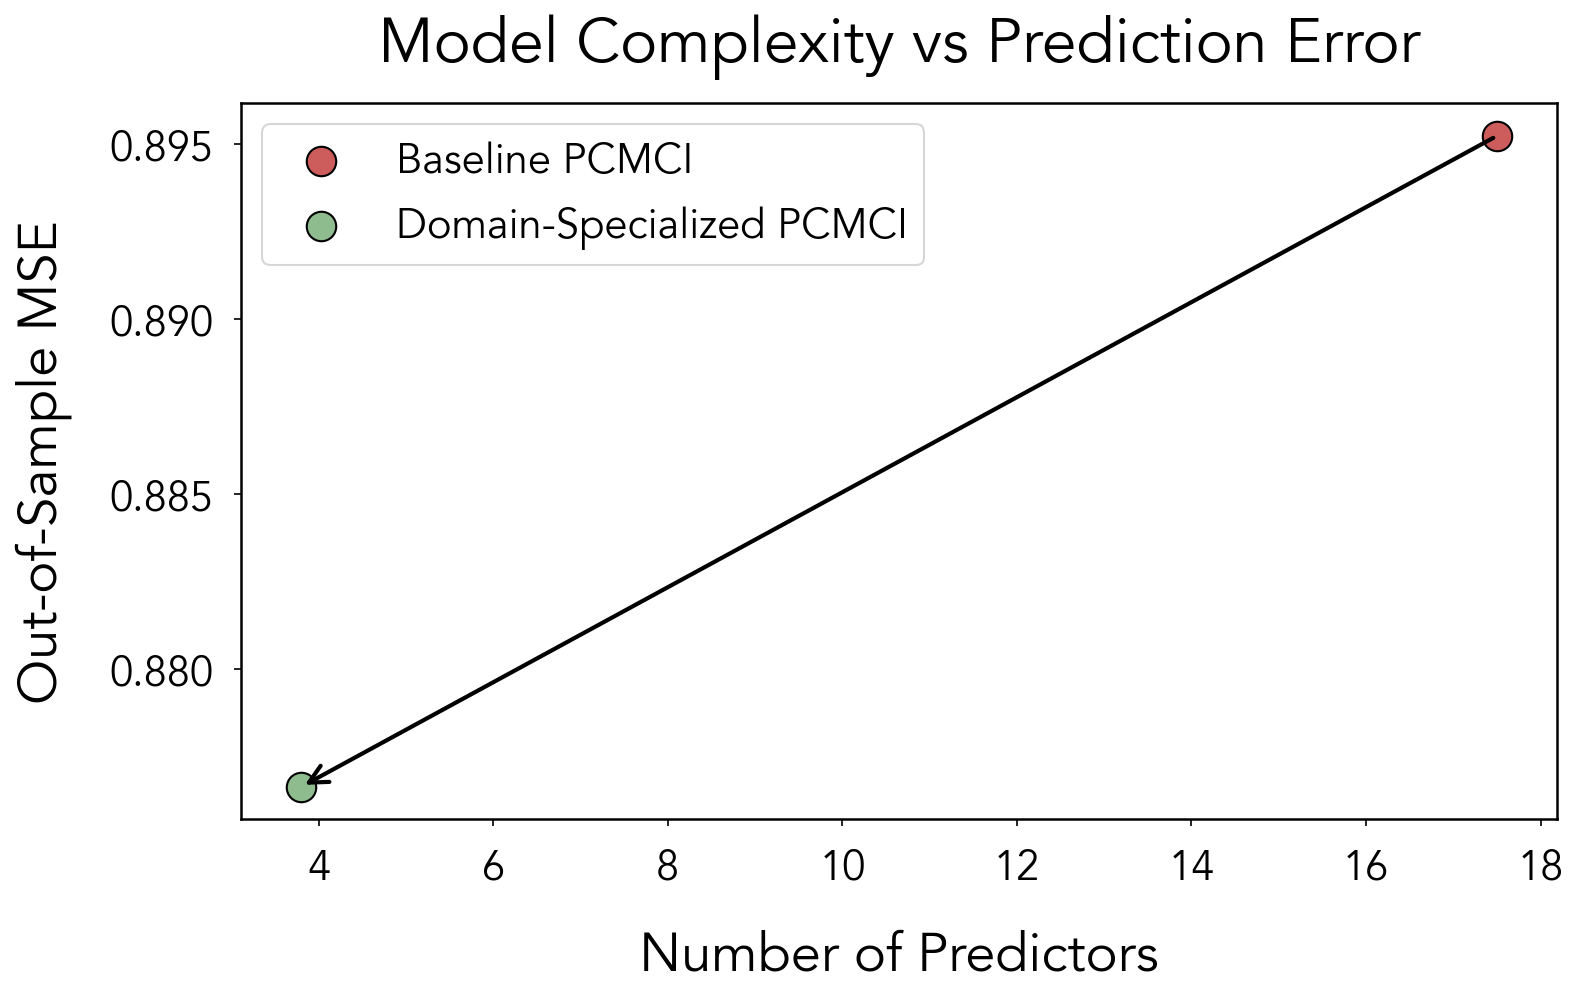

In [86]:
fig, ax = plt.subplots(figsize=(12,8))

ax.scatter(baseline_num_preds, baseline_mse,
           s=200, color="indianred", edgecolor="black",
           label="Baseline PCMCI")

ax.scatter(specialized_num_preds, specialized_mse,
           s=200, color="darkseagreen", edgecolor="black",
           label="Domain-Specialized PCMCI")

ax.annotate(
    "",
    xy=(specialized_num_preds, specialized_mse),
    xytext=(baseline_num_preds, baseline_mse),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.set_xlabel("Number of Predictors", labelpad=18)
ax.set_ylabel("Out-of-Sample MSE", labelpad=18)
ax.set_title(
    "Model Complexity vs Prediction Error",
    pad=20,
)

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend()

plt.tight_layout(pad=2.5)
plt.show()

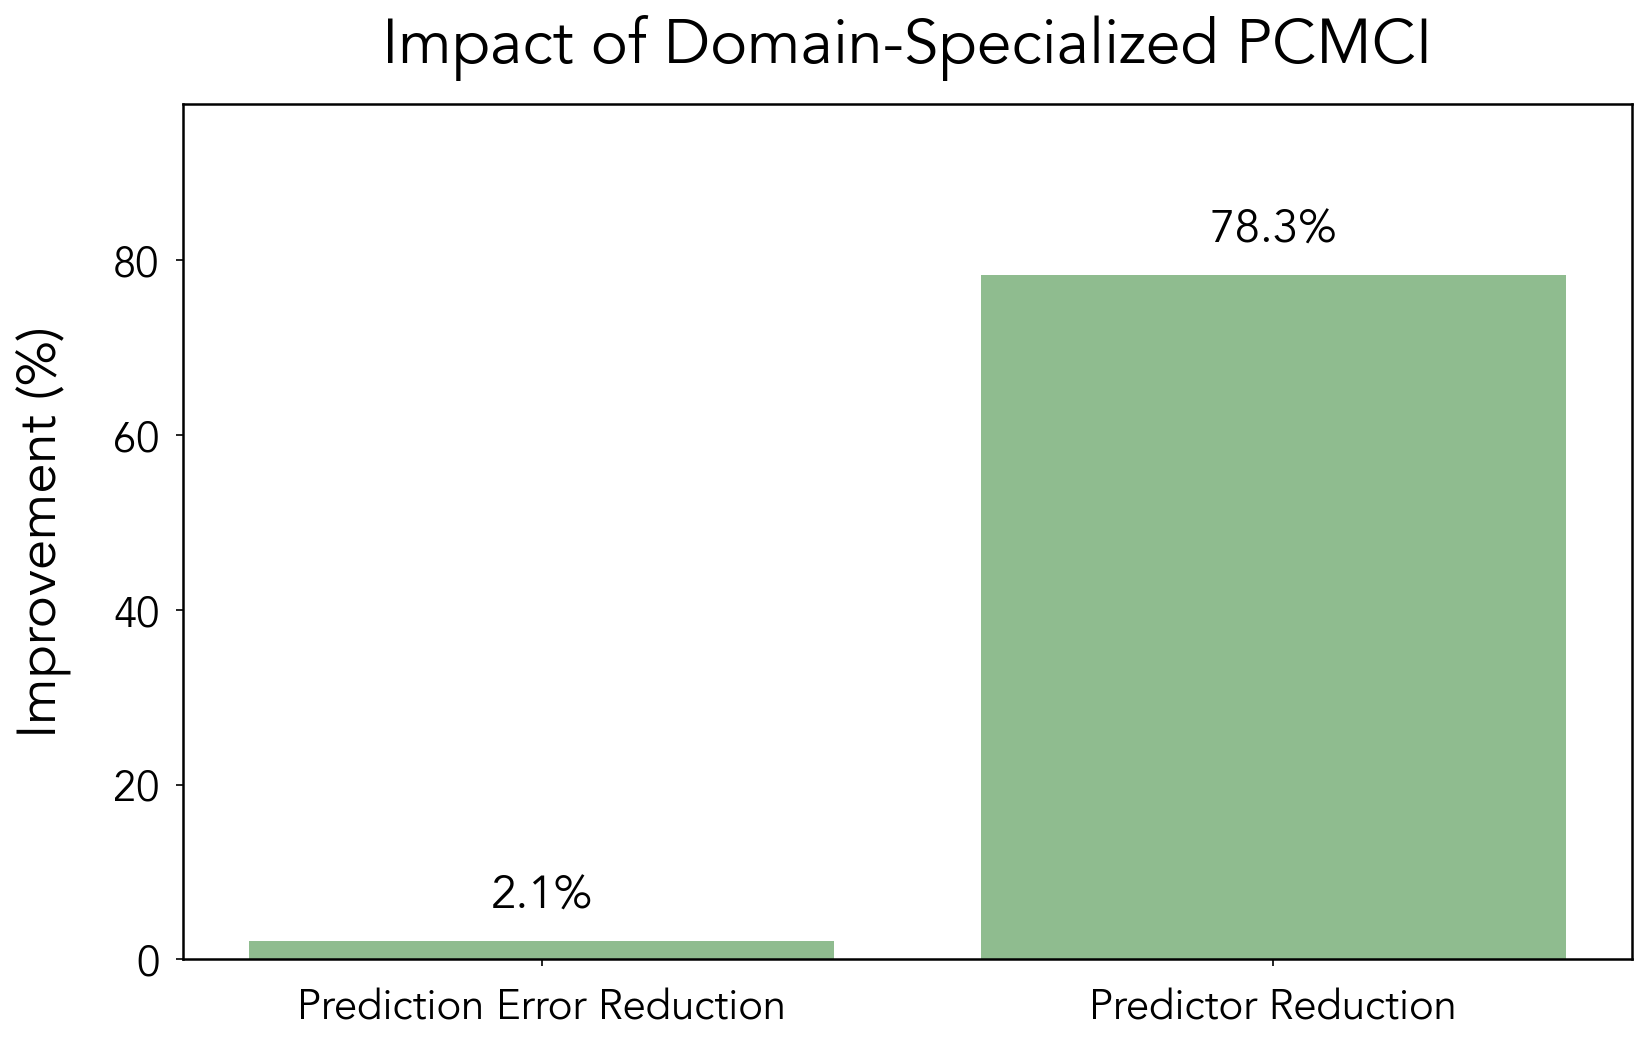

In [90]:
fig, ax = plt.subplots(figsize=(12,8))

bars = ax.bar(metrics, values, color="darkseagreen")

# vertical headroom above bars
ax.set_ylim(0, max(values) * 1.25)

# axis label padding
ax.set_ylabel("Improvement (%)", labelpad=20)

# padding around tick labels
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=8)

# title padding
ax.set_title("Impact of Domain-Specialized PCMCI", pad=20)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + max(values)*0.03,
            f"{height:.1f}%",
            ha='center',
            va='bottom')

plt.tight_layout(pad=2)
plt.show()